## Steps 

1. Getting the data ready
2. Choosing the right algorithm/ estimator for our problem
3. Fit the model/algorithm and use it to make predicitoins on out data
4. Evulate a model
5. Improve a model
6. Save and load a trained model

In [1]:
import pandas as pd
import numpy as np
hd = pd.read_csv('Data/heart-disease.csv')
hd

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [2]:
# Create Features data
X = hd.drop('target', axis=1)

# Create y (labels)
y = hd['target']

# Choosing Right algorithms 
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()

clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [3]:
# Fit the model
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)

clf.fit(X_train, y_train);

In [4]:
y_label = clf.predict(X_test)

In [5]:
y_test

11     1
133    1
136    1
110    1
166    0
      ..
86     1
119    1
105    1
235    0
94     1
Name: target, Length: 61, dtype: int64

In [6]:
# evulate the model

clf.score(X_train, y_train)

1.0

In [7]:
clf.score(X_test, y_test)


0.8032786885245902

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(classification_report(y_test, y_label))

              precision    recall  f1-score   support

           0       0.85      0.73      0.79        30
           1       0.77      0.87      0.82        31

    accuracy                           0.80        61
   macro avg       0.81      0.80      0.80        61
weighted avg       0.81      0.80      0.80        61



In [9]:
confusion_matrix(y_test, y_label)

array([[22,  8],
       [ 4, 27]])

In [10]:
accuracy_score(y_test, y_label)

0.8032786885245902

In [11]:
# Improving a model

np.random.seed(42)
for i in range (10,100, 10):
    print(f"Trying the model with {i} estimators....")
    clf = RandomForestClassifier(n_estimators=i).fit(X_train, y_train)
    print(f"Model accuracy on test set: {clf.score(X_test, y_test)*100:.2f}")
    print('')

Trying the model with 10 estimators....
Model accuracy on test set: 77.05

Trying the model with 20 estimators....
Model accuracy on test set: 75.41

Trying the model with 30 estimators....


Model accuracy on test set: 73.77

Trying the model with 40 estimators....
Model accuracy on test set: 77.05

Trying the model with 50 estimators....
Model accuracy on test set: 75.41

Trying the model with 60 estimators....
Model accuracy on test set: 78.69

Trying the model with 70 estimators....
Model accuracy on test set: 78.69

Trying the model with 80 estimators....
Model accuracy on test set: 83.61

Trying the model with 90 estimators....
Model accuracy on test set: 78.69



In [12]:
# Sacve the mdoel and load it 

import pickle
pickle.dump(clf, open('random_forst_model.pkl', 'wb'))

In [13]:
load = pickle.load(open('random_forst_model.pkl', 'rb'))
load.score(X_test, y_test)

0.7868852459016393

In [14]:
car_sales = pd.read_csv('Data/car-sales-extended.csv')
car_sales.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431,4,15323
1,BMW,Blue,192714,5,19943
2,Honda,White,84714,4,28343
3,Toyota,White,154365,4,13434
4,Nissan,Blue,181577,3,14043


In [17]:
# from sklearn.ensemble import RandomForestRegressor

# # Getting data ready
# X = car_sales.drop('Price', axis=1)
# y = car_sales.Price

# # train test split 
# X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.2)

# # Fitting model 
# model = RandomForestRegressor()

# model.fit(X_train, y_train)
# model.score(X_test, y_test)

ValueError: could not convert string to float: 'Honda'

Since the catagorical variables ['Make', 'Color', 'Door'] are non-numeric we have to conver them into numeric values using "One Hot Encoder"

In [18]:
# Turning the categories into numbers

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ['Make', 'Colour', 'Doors']

one_hot = OneHotEncoder()
transformer = ColumnTransformer([('one_hot',
                                  one_hot,
                                  categorical_features)],
                                  remainder='passthrough')

transformed_X = transformer.fit_transform(X)
transformed_X

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 3.54310e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+00, 1.92714e+05],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 8.47140e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 6.66040e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.15883e+05],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.48360e+05]])

In [19]:
car_sales.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431,4,15323
1,BMW,Blue,192714,5,19943
2,Honda,White,84714,4,28343
3,Toyota,White,154365,4,13434
4,Nissan,Blue,181577,3,14043


In [20]:
pd.DataFrame(transformed_X)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,35431.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,192714.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,84714.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,154365.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,181577.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,35820.0
996,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,155144.0
997,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,66604.0
998,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,215883.0


In [21]:
np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(transformed_X, y, test_size=.2)

model= RandomForestRegressor()

model.fit(X_train, y_train)

model.score(X_test, y_test)

0.3235867221569877

In [22]:
dummies = pd.get_dummies(car_sales[['Make', 'Colour', 'Doors']])
dummies

,Doors,Make_BMW,Make_Honda,Make_Nissan,Make_Toyota,Colour_Black,Colour_Blue,Colour_Green,Colour_Red,Colour_White
0,4,False,True,False,False,False,False,False,False,True
1,5,True,False,False,False,False,True,False,False,False
2,4,False,True,False,False,False,False,False,False,True
3,4,False,False,False,True,False,False,False,False,True
4,3,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...
995,4,False,False,False,True,True,False,False,False,False
996,3,False,False,True,False,False,False,False,False,True
997,4,False,False,True,False,False,True,False,False,False
998,4,False,True,False,False,False,False,False,False,True


## Dealing with missing data

1. Filling them with some values (aka imputation)
2. Removing the samples with missing data completly


In [23]:
car_sales_missing = pd.read_csv('Data/car-sales-extended-missing-data.csv')
car_sales_missing.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0


In [24]:
car_sales_missing.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

In [25]:
X = car_sales_missing.drop('Price', axis=1)
y= car_sales_missing.Price


In [26]:
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.compose import ColumnTransformer

# categorical_features = ['Make', 'Colour', 'Doors']

# one_hot = OneHotEncoder()

# transformer = ColumnTransformer([('one_hot',
#                                  one_hot,
#                                  categorical_features)],
#                                  remainder='passthrough')

# transformed_X = transformer.fit_transform(X)
# transformed_X;

In [27]:
X_train, X_test, y_train, y_test = train_test_split(transformed_X, y, test_size=.2)
model = RandomForestRegressor()
model.fit(X_train, y_train)
model.score(X_test, y_test)

ValueError: Input y contains NaN.

In [ ]:
car_sales_missing.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

#### Filling the missing values 

In [28]:
car_sales_missing['Doors'].value_counts()

Doors
4.0    811
5.0     75
3.0     64
Name: count, dtype: int64

In [29]:
# filling the 'Make' columns 
car_sales_missing['Make'].fillna('missing', inplace=True)

# filling the 'Colour' columns 
car_sales_missing['Colour'].fillna('missing', inplace=True)

# filling the 'Doors' columns 
car_sales_missing['Doors'].fillna(4, inplace=True)

# filling the 'Odometer (KM)' columns
car_sales_missing['Odometer (KM)'].fillna(car_sales_missing['Odometer (KM)'].mean(), inplace=True)


/tmp/ipykernel_6623/2277843492.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  car_sales_missing['Make'].fillna('missing', inplace=True)
/tmp/ipykernel_6623/2277843492.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [30]:
car_sales_missing.isna().sum()

Make              0
Colour            0
Odometer (KM)     0
Doors             0
Price            50
dtype: int64

In [31]:
# Removing the missing Price values from the dataset

car_sales_missing.dropna(inplace= True)

In [32]:
car_sales_missing.isna().sum()

Make             0
Colour           0
Odometer (KM)    0
Doors            0
Price            0
dtype: int64

In [33]:
X = car_sales_missing.drop("Price", axis=1)
y = car_sales_missing['Price']


In [34]:
categorical_features = ['Make', 'Colour', 'Doors']

one_hot = OneHotEncoder()

transformer = ColumnTransformer([('one_hot',
                                 one_hot,
                                 categorical_features)],
                                 remainder='passthrough')

transformed_X = transformer.fit_transform(X)
transformed_X;

In [35]:
# y_flat = np.argmax(y, axis=1)
X_train, X_test, y_train, y_test = train_test_split(transformed_X, y, test_size=.2)

model =  RandomForestRegressor()

model.fit(X_train, y_train)
model.score(X_test, y_test)

0.190541879092734

Once your data is all in numerical format, there's one more transformation you'll probably want to do to it.

It's called Feature Scaling.

In other words, making sure all of your numerical data is on the same scale.

For example, say you were trying to predict the sale price of cars and the number of kilometres on their odometers varies from 6,000 to 345,000 but the median previous repair cost varies from 100 to 1,700. A machine learning algorithm may have trouble finding patterns in these wide-ranging variables.

To fix this, there are two main types of feature scaling.

    Normalization (also called min-max scaling) - This rescales all the numerical values to between 0 and 1, with the lowest value being close to 0 and the highest previous value being close to 1. Scikit-Learn provides functionality for this in the MinMaxScalar class.

    Standardization - This subtracts the mean value from all of the features (so the resulting features have 0 mean). It then scales the features to unit variance (by dividing the feature by the standard deviation). Scikit-Learn provides functionality for this in the StandardScalar class.

A couple of things to note.

    Feature scaling usually isn't required for your target variable.

    Feature scaling is usually not required with tree-based models (e.g. Random Forest) since they can handle varying features.

### Filling the missing values with Scikit-learn


In [36]:
car_sales_missing = pd.read_csv('Data/car-sales-extended-missing-data.csv')

car_sales_missing.dropna(subset=['Price'], inplace=True)

X = car_sales_missing.drop('Price', axis=1)
y = car_sales_missing.Price


In [37]:
car_sales_missing.isna().sum()


Make             47
Colour           46
Odometer (KM)    48
Doors            47
Price             0
dtype: int64

In [38]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# filling categorical values with 'missing' and numbeical values with mean
cat_imputer = SimpleImputer(strategy="constant", fill_value= "mmissing")
door_imputer = SimpleImputer(strategy="constant", fill_value=4)
odo_imputer = SimpleImputer(strategy="mean")

# defining columns
cat_features = ['Make', 'Colour']
door_features = ['Doors']
odo_features = ['Odometer (KM)']

# Create an imputer 
imputer = ColumnTransformer([
    ('cat_imputer', cat_imputer, cat_features),
    ('door_imputer', door_imputer, door_features ),
    ('odo_imputers', odo_imputer, odo_features)
])

# Transform the data
filled_X = imputer.fit_transform(X)
filled_X

array([['Honda', 'White', 4.0, 35431.0],
       ['BMW', 'Blue', 5.0, 192714.0],
       ['Honda', 'White', 4.0, 84714.0],
       ...,
       ['Nissan', 'Blue', 4.0, 66604.0],
       ['Honda', 'White', 4.0, 215883.0],
       ['Toyota', 'Blue', 4.0, 248360.0]], dtype=object)

In [39]:
car_sales_filled = pd.DataFrame(filled_X, \
                                columns=['Make', 'Colour', 'Doors', 'Odometer (KM)'])
car_sales_filled.head()

,Make,Colour,Doors,Odometer (KM)
0,Honda,White,4.0,35431.0
1,BMW,Blue,5.0,192714.0
2,Honda,White,4.0,84714.0
3,Toyota,White,4.0,154365.0
4,Nissan,Blue,3.0,181577.0


In [40]:
car_sales_filled.isna().sum()

Make             0
Colour           0
Doors            0
Odometer (KM)    0
dtype: int64

In [41]:
categorical_features = ['Make', 'Colour', 'Doors']
one_hot = OneHotEncoder()
transformer = ColumnTransformer([
    ('one_hot', one_hot, categorical_features)
],remainder= 'passthrough')

transformed_X = transformer.fit_transform(car_sales_filled)
transformed_X

<950x15 sparse matrix of type '<class 'numpy.float64'>'
	with 3800 stored elements in Compressed Sparse Row format>

In [42]:
np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(transformed_X, y, test_size=.2)

model = RandomForestRegressor()
model.fit(X_train, y_train)
model.score(X_test, y_test)


0.21990196728583944

### Picking a machne learning model for a regression problem 

In [43]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [44]:
housing_data = pd.DataFrame(housing['data'], columns=housing['feature_names'])
housing_data

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [45]:
housing_data['target'] = housing['target']
housing_data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [46]:
len(housing_data)

20640

In [47]:
housing_data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Ensemble method combines the predictions of several base estimators given learning algorithm in order to improve generalizablity/ robustness of a single estimators

In [48]:
# Importing the algorithm 
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# settig the random seed
np.random.seed(42)

# getting the data ready 
X = housing_data.drop('target', axis=1)
y = housing_data.target

# splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)

# instantiateing  the object 
model = RandomForestRegressor()

# fitting the model 
model.fit(X_train, y_train)

# gettig the score 
model.score(X_test, y_test)



0.8066196804802649

In [53]:
# Classification Models
from sklearn.datasets import load_iris

iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [54]:
iris_data = pd.DataFrame(iris['data'], columns=iris['feature_names'])
iris_data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [55]:
# iris_data['target'] = iris['target']
iris_data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [56]:
# # Importing the algorithms 
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import train_test_split

# # Getting the data ready
# X = iris_data.drop('target', axis=1)
# y = iris_data.target

# # splitting the data
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# # instantiating the model
# clf = RandomForestClassifier()

# # fitting the classifier
# clf.fit(X_train, y_train)

# # getting the score 
# clf.score(X_test, y_test)


KeyError: "['target'] not found in axis"

In [57]:
heart_disease = pd.read_csv('Data/heart-disease.csv')
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [58]:
np.random.seed(42)

X = heart_disease.drop('target', axis=1)
y = heart_disease.target

X_train, X_test, y_train, y_test = train_test_split(X, y ,test_size=0.2)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

clf.score(X_test, y_test)


0.8524590163934426

In [59]:
len(heart_disease)

303

In [60]:
from sklearn.svm import LinearSVC
np.random.seed(42)

X = heart_disease.drop('target', axis=1)
y = heart_disease.target

X_train, X_test, y_train, y_test = train_test_split(X, y ,test_size=0.2)

clf = LinearSVC()
clf.fit(X_train, y_train)

clf.score(X_test, y_test)



/home/vishnu/MyFiles/Programming/AI & ML/.env/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/vishnu/MyFiles/Programming/AI & ML/.env/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


0.8688524590163934

### Fittng a machine learning model


In [61]:
# Setting the seed
np.random.seed(42)

# getting the data ready
X = heart_disease.drop('target', axis=1)
y = heart_disease.target

# splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y ,test_size=0.2)

# instantiating the model
clf = RandomForestClassifier()

# Fitting the model
clf.fit(X_train, y_train)

# getting the score of the model
clf.score(X_test, y_test)


0.8524590163934426

### Making the predictions using a machine learning model

There are two ways 

1. `predict()`
2. `predict_proba()`

In [62]:
clf.predict(X_test)

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [63]:
np.array([y_test])

array([[0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
        0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0]])

In [64]:
# Comparing predictions to truth labels to evulate the model
y_preds = clf.predict(X_test)
np.mean(y_preds == y_test)

0.8524590163934426

In [65]:
clf.score(X_test, y_test)

0.8524590163934426

In [66]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_preds)


0.8524590163934426

In [67]:
# Making the predictins with predict_proba()
clf.predict_proba(X_test[:5])

array([[0.89, 0.11],
       [0.49, 0.51],
       [0.43, 0.57],
       [0.84, 0.16],
       [0.18, 0.82]])

In [68]:
clf.predict(X_test[:5])

array([0, 1, 1, 0, 1])

In [69]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# getting the data ready
X = housing_data.drop('target', axis=1)
y = housing_data.target

# splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.20)

# Instantiating the model
model = RandomForestRegressor()

# fitting the model 
model.fit(X_train, y_train)

# making predictions
y_preds = model.predict(X_test)

In [70]:
y_preds[:10]

array([1.7471   , 1.23883  , 2.3498401, 1.93005  , 1.27568  , 0.94658  ,
       2.03018  , 1.0961002, 3.176421 , 1.62525  ])

In [71]:
np.array([ y_test[:10]])

array([[1.339  , 1.291  , 1.996  , 1.856  , 1.121  , 0.93   , 1.906  ,
        0.733  , 5.00001, 1.403  ]])

### Regression model evulation 

In [72]:
# compare the predictions to the truth 
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test, y_preds)

0.3268376173691862

## Evulating the model

There are three ways
1. estimators  built-in `socre()` method
2. The `scoring` parameter
3. Problem-specific metric functions

In [74]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

np.random.seed(42)
# getting the data ready
X = heart_disease.drop('target', axis=1)
y = heart_disease.target

# splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.20)

# Instantiating the model
model = RandomForestRegressor()

# fitting the model 
model.fit(X_train, y_train);

In [75]:
clf.score(X_train, y_train),clf.score(X_test, y_test)

(1.0, 0.8524590163934426)

In [76]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

np.random.seed(42)

# getting the data ready
X = housing_data.drop('target', axis=1)
y = housing_data.target

# splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.20)

# Instantiating the model
model = RandomForestRegressor()

# fitting the model 
model.fit(X_train, y_train)


RandomForestRegressor()

In [77]:
# the default score() evulation matric is r_squared for regression algorithms 
# getting the score
model.score(X_train, y_train), model.score(X_test, y_test)

(0.9736828565983116, 0.8066196804802649)

In [78]:
from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

np.random.seed(42)
# getting the data ready
X = heart_disease.drop('target', axis=1)
y = heart_disease.target

# splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.20)

# Instantiating the model
clf = RandomForestClassifier()
# fitting the model 
train = clf.fit(X_train, y_train);

cross_val_score(clf, X, y)

array([0.81967213, 0.86885246, 0.81967213, 0.78333333, 0.76666667])

In [79]:
np.random.seed(42)

# single training and test split 
clf_single_split = clf.score(X_test, y_test)

# taking a mean of 5 folds cross_validation_score
clf_cross_val_score = np.mean(cross_val_score(clf, X, y))

# default scoring parameter for classifiers is mean accuracy 
# clf.score()

# comparing the two 
clf_cross_val_score, clf_single_split


(0.8248087431693989, 0.8524590163934426)

In [80]:
# import matplotlib.pyplot as plt
# import numpy as np
# from sklearn.model_selection import cross_val_predict
# from sklearn.metrics import plot_confusion_matrix

# # Train your model on the training data
# clf.fit(X_train, y_train)

# # Predict the target variable on the training data
# y_train_pred = clf.predict(X_train)

# # Plot training data
# plt.figure(figsize=(8, 6))

# # Plot actual vs predicted
# plt.scatter(y_train, y_train_pred)
# plt.xlabel("True Values")
# plt.ylabel("Predictions")

# # Plot perfect predictions line
# plt.plot([0, 1], [0, 1], '--k')

# # Show plot
# plt.show()



ImportError: cannot import name 'plot_confusion_matrix' from 'sklearn.metrics' (/home/vishnu/MyFiles/Programming/AI & ML/.env/lib/python3.12/site-packages/sklearn/metrics/__init__.py)

### Classification model evualtion metrics 

1. Accuracy
2. Area under ROC curve
3. Confusion matrix
4. Classification report

**Accuracy**

In [81]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X = heart_disease.drop('target', axis=1)
y = heart_disease.target

clf = RandomForestClassifier()

clf_cross_val_score = cross_val_score(clf, X, y)

np.mean(clf_cross_val_score)

0.8248087431693989

In [82]:
print(f"Heart Disease classificaion Cross-Validation Accuracy: {np.mean(clf_cross_val_score) *100:.2f}%")

Heart Disease classificaion Cross-Validation Accuracy: 82.48%


**Area under the reciver operating characterstic curve (AUC/ROC curve)**

#### ROC curves are comparision between True Positive Rate(TPR) and False Positive Rate(FPR).


* TPR = Model predicts 1 when truth is 1
* FPR = Model predicts 1 when truth is 0
* TNR = Model predicts 0 when truth is 0 (True Negative Rate)
* FNR = Model predicts 0 wehn truth is 0 (False Negative Rate)



In [88]:


X = heart_disease.drop('target', axis=1)
y = heart_disease.target

# Train test split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)

# fit classifier
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# predicting 
y_preds = clf.predict_proba(X_test)



In [89]:
y_preds[:10]

array([[0.66, 0.34],
       [0.62, 0.38],
       [0.07, 0.93],
       [0.47, 0.53],
       [0.38, 0.62],
       [0.39, 0.61],
       [0.32, 0.68],
       [0.84, 0.16],
       [0.33, 0.67],
       [0.13, 0.87]])

In [95]:
y_probs_positive = y_preds[:,1]
y_probs_positive[:10]

array([0.34, 0.38, 0.93, 0.53, 0.62, 0.61, 0.68, 0.16, 0.67, 0.87])

In [96]:
from sklearn.metrics import roc_curve
# calculating fpr, tpr and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_probs_positive)

fpr

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.03703704, 0.07407407, 0.07407407,
       0.11111111, 0.11111111, 0.14814815, 0.18518519, 0.18518519,
       0.2962963 , 0.2962963 , 0.40740741, 0.48148148, 0.48148148,
       0.55555556, 0.66666667, 0.74074074, 1.        ])

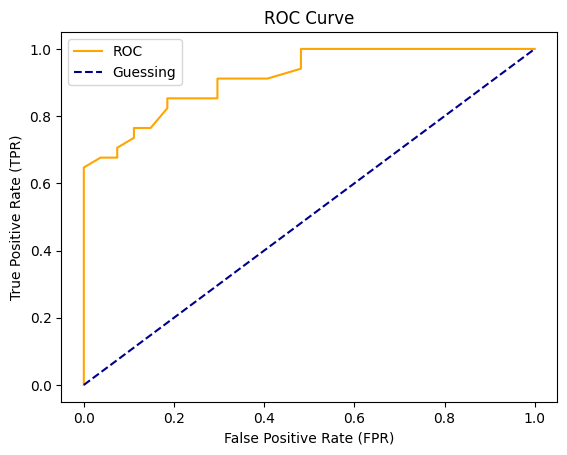

In [100]:
import matplotlib.pyplot as plt 

def plot_roc(fpr, tpr):
    plt.plot(fpr, tpr, color='orange', label='ROC')

    plt.plot([0,1], [0,1], color='darkblue', linestyle='--', label='Guessing')

    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel('True Positive Rate (TPR)')
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

plot_roc(fpr, tpr)

In [102]:
from sklearn.metrics import roc_auc_score
"""
Area Under the Curve (AUC): The AUC measures the area under the ROC curve. It provides a single scalar value
that quantifies the overall performance of the classifier across all possible classification thresholds.
"""
roc_auc_score(y_test, y_probs_positive)

0.9172113289760349

**Confusion Matrix** 

Its a quick way to compare the labels a model predicts and the actual labels it was to predict

In [104]:
from sklearn.metrics import confusion_matrix

y_preds = clf.predict(X_test)

confusion_matrix(y_test, y_preds)

array([[20,  7],
       [ 5, 29]])

In [106]:
pd.crosstab(y_test,
            y_preds,
            rownames=['Actual Labels'],
            colnames=['Predicted Labels'])

Predicted Labels,0,1
Actual Labels,,
0,20,7
1,5,29


In [107]:
len(y_preds)

61

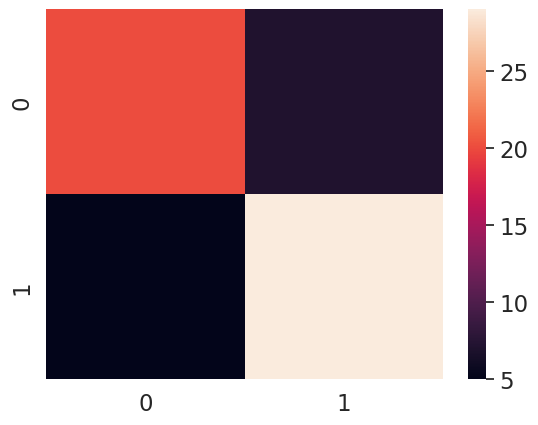

In [109]:
import seaborn as sns

# set font scale
sns.set(font_scale=1.5)

# set the font scale
conf_mat = confusion_matrix(y_test, y_preds)

# plot it using seaborn
sns.heatmap(conf_mat);


In [112]:
!pip list

Package                 Version
----------------------- -----------
absl-py                 2.1.0
asttokens               2.4.1
astunparse              1.6.3
certifi                 2024.2.2
charset-normalizer      3.3.2
comm                    0.2.2
contourpy               1.2.1
cycler                  0.12.1
debugpy                 1.8.1
decorator               5.1.1
executing               2.0.1
flatbuffers             24.3.25
fonttools               4.51.0
gast                    0.5.4
google-pasta            0.2.0
grpcio                  1.63.0
h5py                    3.11.0
idna                    3.7
ipykernel               6.29.4
ipython                 8.24.0
jedi                    0.19.1
joblib                  1.4.2
jupyter_client          8.6.1
jupyter_core            5.7.2
keras                   3.3.3
kiwisolver              1.4.5
libclang                18.1.1
Markdown                3.6
markdown-it-py          3.0.0
MarkupSafe              2.1.5
matplotlib             

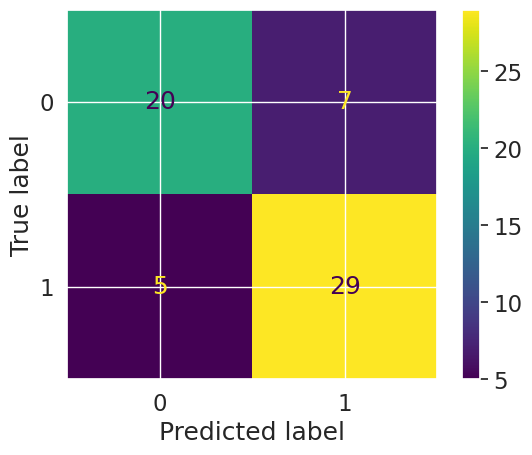

In [113]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()
plt.show()

In [114]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.80      0.74      0.77        27
           1       0.81      0.85      0.83        34

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



In [121]:
# where precision and reacall becoms useful 
disease_true = np.zeros(10000)

disease_true[10] = 1 # only one positive case

disease_preds = np.zeros(10000) # model predicts everty class as 0

df = pd.DataFrame(classification_report(disease_true,disease_preds,  output_dict=True))
df

/home/vishnu/MyFiles/Programming/AI & ML/.env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/vishnu/MyFiles/Programming/AI & ML/.env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/vishnu/MyFiles/Programming/AI & ML/.env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

,0.0,1.0,accuracy,macro avg,weighted avg
precision,0.99990,0.0,0.9999,0.499950,0.99980
recall,1.00000,0.0,0.9999,0.500000,0.99990
f1-score,0.99995,0.0,0.9999,0.499975,0.99985
support,9999.00000,1.0,0.9999,10000.000000,10000.00000


### Regression model evulation matrix

1. R-Square or Coefficent of determination 
2. Mean Absolute Error(MAE)
3. Mean Square Error (MSE)

In [122]:
from sklearn.ensemble import RandomForestRegressor
 
np.random.seed(42)

X = housing_data.drop('target', axis=1)
y = housing_data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)

model = RandomForestRegressor()
model.fit(X_train, y_train)


RandomForestRegressor()

In [123]:
model.score(X_test, y_test)

0.8066196804802649

In [124]:
housing_data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [126]:
model.score(X_test, y_test)

0.8066196804802649

In [127]:
 y_test

20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
          ...   
15362    2.63300
16623    2.66800
18086    5.00001
2144     0.72300
3665     1.51500
Name: target, Length: 4128, dtype: float64

In [128]:
y_test.mean()

2.0550030959302323

In [129]:
from sklearn.metrics import r2_score

# filling the arrays with the y_tes tmean 
y_test_mean = np.full(len(y_test), y_test.mean())

In [131]:
y_test_mean[:10]

array([2.0550031, 2.0550031, 2.0550031, 2.0550031, 2.0550031, 2.0550031,
       2.0550031, 2.0550031, 2.0550031, 2.0550031])

In [132]:
r2_score(y_true=y_test,
         y_pred=y_test_mean)

0.0

In [134]:
r2_score(y_true=y_test,
         y_pred=y_test)

1.0